# 08 — สังคมสูงวัย vs พฤติกรรมการเลือกตั้ง
## ลำปาง เขต 2

วิเคราะห์ว่าตำบลที่มีผู้สูงอายุเยอะ มีพฤติกรรมการเลือกตั้งต่างจากตำบลที่คนอายุน้อยกว่าอย่างไร

- ข้อมูลประชากรรายอายุ: DOPA ม.ค. 2569 (รายตำบล)
- ข้อมูลเลือกตั้ง: ปี 2569 (รายหน่วย aggregate เป็นรายตำบล)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy import stats

mpl.rcParams['font.family'] = 'Tahoma'
mpl.rcParams['font.size'] = 12
try:
    mpl.font_manager.fontManager.addfont('../thsarabunnew-webfont.ttf')
    mpl.rcParams['font.family'] = 'TH Sarabun New'
    mpl.rcParams['font.size'] = 16
except:
    pass

## 1. โหลดและเตรียมข้อมูล

In [2]:
# โหลดข้อมูลประชากร
pop = pd.read_csv('../cleaned/pop_age_by_tambon.csv')

# สร้างกลุ่มอายุ
pop['age_group'] = pd.cut(pop['age'], bins=[-1, 14, 24, 59, 200],
                          labels=['0-14 เด็ก', '15-24 วัยรุ่น', '25-59 วัยทำงาน', '60+ สูงวัย'])

# Aggregate รายตำบล
pop_tambon = pop.groupby(['district', 'sub_district', 'age_group'], observed=True)['total'].sum().unstack(fill_value=0)
pop_tambon['pop_total'] = pop_tambon.sum(axis=1)
pop_tambon['pct_elderly'] = pop_tambon['60+ สูงวัย'] / pop_tambon['pop_total'] * 100
pop_tambon['pct_youth'] = pop_tambon['15-24 วัยรุ่น'] / pop_tambon['pop_total'] * 100
pop_tambon['pct_working'] = pop_tambon['25-59 วัยทำงาน'] / pop_tambon['pop_total'] * 100
pop_tambon = pop_tambon.reset_index()

print(f'ตำบลทั้งหมด: {len(pop_tambon)}')
pop_tambon[['district', 'sub_district', 'pop_total', 'pct_elderly', 'pct_youth']].head(10)

ตำบลทั้งหมด: 39


age_group,district,sub_district,pop_total,pct_elderly,pct_youth
0,งาว,นาแก,3343,26.144182,10.738857
1,งาว,บ้านร้อง,5815,29.165950,9.544282
2,งาว,บ้านหวด,4705,20.233794,13.156217
3,งาว,บ้านอ้อน,4247,27.289852,9.324229
4,งาว,บ้านแหง,5822,31.071797,9.429749
5,งาว,บ้านโป่ง,6323,28.467500,9.457536
6,งาว,ปงเตา,6685,29.289454,9.334331
7,งาว,หลวงใต้,5191,30.764785,10.113658
8,งาว,แม่ตีบ,4118,26.542011,8.305002
9,วังเหนือ,ทุ่งฮั้ว,5125,30.985366,9.014634


In [3]:
# โหลดผลเลือกตั้ง
results = pd.read_csv('../cleaned/master_results_cleaned.csv')
summary = pd.read_csv('../cleaned/master_summary_cleaned.csv')

# แก้ชื่อตำบลที่สะกดต่างกันระหว่าง 2 dataset
tambon_rename = {
    'บ้านหวอด': 'บ้านหวด',       # งาว
    'หลวงเหนือ': 'หลวงใต้',       # งาว (สันนิษฐานว่าเป็นตำบลเดียวกัน)
    'ทุ่งกว้าง': 'ทุ่งกว๋าว',      # เมืองปาน
    'แจ้ห่ม(ในเขต)': 'แจ้ห่ม',     # แจ้ห่ม — รวมในเขต+นอกเขตเป็นตำบลเดียว
    'แจ้ห่ม(นอกเขต)': 'แจ้ห่ม',
}
results['sub-district'] = results['sub-district'].replace(tambon_rename)
summary['sub-district'] = summary['sub-district'].replace(tambon_rename)

# ตัด นอกเขต ออก
results = results[results['district'] != 'นอกเขต']
summary = summary[summary['district'] != 'นอกเขต']

# Aggregate ผลบัญชีรายชื่อ รายตำบล
pl = results[results['type'] == 'บช'].copy()
pl_tambon = pl.groupby(['district', 'sub-district', 'name'])['score'].sum().reset_index()

# หาพรรคที่ชนะในแต่ละตำบล
idx = pl_tambon.groupby(['district', 'sub-district'])['score'].idxmax()
winner = pl_tambon.loc[idx, ['district', 'sub-district', 'name', 'score']].copy()
winner.columns = ['district', 'sub_district', 'winner_party', 'winner_score']

# คะแนนรวมรายตำบล
total_by_tambon = pl_tambon.groupby(['district', 'sub-district'])['score'].sum().reset_index()
total_by_tambon.columns = ['district', 'sub_district', 'total_score']

winner = winner.merge(total_by_tambon, on=['district', 'sub_district'])
winner['winner_pct'] = winner['winner_score'] / winner['total_score'] * 100

# คะแนนพรรคหลัก
main_parties = ['ประชาชน', 'เพื่อไทย', 'กล้าธรรม', 'ภูมิใจไทย']
for party in main_parties:
    party_score = pl_tambon[pl_tambon['name'] == party][['district', 'sub-district', 'score']].copy()
    party_score.columns = ['district', 'sub_district', f'score_{party}']
    winner = winner.merge(party_score, on=['district', 'sub_district'], how='left')
    winner[f'score_{party}'] = winner[f'score_{party}'].fillna(0)
    winner[f'pct_{party}'] = winner[f'score_{party}'] / winner['total_score'] * 100

# สถิติบัตร (บช) รายตำบล
sum_tambon = summary[summary['type'] == 'บช'].groupby(['district', 'sub-district']).agg(
    total_ballots=('total_ballots', 'sum'),
    valid_ballots=('valid_ballots', 'sum'),
    invalid_ballots=('invalid_ballots', 'sum'),
    no_vote_ballots=('no_vote_ballots', 'sum'),
).reset_index()
sum_tambon.columns = ['district', 'sub_district', 'total_ballots', 'valid_ballots', 'invalid_ballots', 'no_vote_ballots']
sum_tambon['turnout_pct'] = sum_tambon['valid_ballots'] / sum_tambon['total_ballots'] * 100
sum_tambon['invalid_pct'] = sum_tambon['invalid_ballots'] / sum_tambon['total_ballots'] * 100

winner = winner.merge(sum_tambon[['district', 'sub_district', 'turnout_pct', 'invalid_pct']], 
                      on=['district', 'sub_district'], how='left')

print(f'ตำบลในข้อมูลเลือกตั้ง: {len(winner)}')
winner.head()

ตำบลในข้อมูลเลือกตั้ง: 33


,district,sub_district,winner_party,winner_score,total_score,winner_pct,score_ประชาชน,pct_ประชาชน,score_เพื่อไทย,pct_เพื่อไทย,score_กล้าธรรม,pct_กล้าธรรม,score_ภูมิใจไทย,pct_ภูมิใจไทย,turnout_pct,invalid_pct
0,งาว,นาแก,ประชาชน,448,1721,26.031377,448,26.031377,354,20.569436,366,21.266705,108,6.275421,64.927007,3.102190
1,งาว,บ้านร้อง,เพื่อไทย,649,2760,23.514493,605,21.920290,649,23.514493,494,17.898551,118,4.275362,60.206612,4.400826
2,งาว,บ้านหวด,ประชาชน,446,1552,28.737113,446,28.737113,428,27.577320,100,6.443299,69,4.445876,55.573770,4.863388
3,งาว,บ้านอ้อน,เพื่อไทย,587,2233,26.287506,500,22.391402,587,26.287506,384,17.196597,110,4.926108,61.424419,4.244186
4,งาว,บ้านแหง,ประชาชน,733,3195,22.942097,733,22.942097,633,19.812207,637,19.937402,182,5.696401,64.895397,5.753138


In [4]:
# Merge ข้อมูลประชากร + เลือกตั้ง
# ชื่อตำบลอาจไม่ตรงกัน 100% — ดู mapping
print('ตำบลในข้อมูลประชากร:', sorted(pop_tambon['sub_district'].unique()))
print()
print('ตำบลในข้อมูลเลือกตั้ง:', sorted(winner['sub_district'].unique()))

ตำบลในข้อมูลประชากร: ['ต้นธงชัย', 'ทุ่งกว๋าว', 'ทุ่งผึ้ง', 'ทุ่งฝาย', 'ทุ่งฮั้ว', 'นาแก', 'นิคมพัฒนา', 'บุญนาคพัฒนา', 'บ่อแฮ้ว', 'บ้านขอ', 'บ้านค่า', 'บ้านร้อง', 'บ้านสา', 'บ้านหวด', 'บ้านอ้อน', 'บ้านเป้า', 'บ้านเสด็จ', 'บ้านเอื้อม', 'บ้านแลง', 'บ้านแหง', 'บ้านโป่ง', 'ปงดอน', 'ปงเตา', 'พิชัย', 'ร่องเคาะ', 'วังซ้าย', 'วังทรายคำ', 'วังทอง', 'วังแก้ว', 'วังใต้', 'วิเชตนคร', 'หลวงใต้', 'หัวเมือง', 'เมืองปาน', 'เมืองมาย', 'แจ้ซ้อน', 'แจ้ห่ม', 'แม่ตีบ', 'แม่สุก']

ตำบลในข้อมูลเลือกตั้ง: ['ทุ่งกว๋าว', 'ทุ่งผึ้ง', 'ทุ่งฮั้ว', 'นาแก', 'บ้านขอ', 'บ้านร้อง', 'บ้านสา', 'บ้านหวด', 'บ้านอ้อน', 'บ้านเสด็จ', 'บ้านแลง', 'บ้านแหง', 'บ้านโป่ง', 'บ้านใหม่', 'ปงดอน', 'ปงเตา', 'ร่องเคาะ', 'วังซ้าย', 'วังทรายคำ', 'วังทอง', 'วังเหนือ', 'วังแก้ว', 'วังใต้', 'วิเชตนคร', 'หลวงใต้', 'หัวเมือง', 'เมืองปาน', 'เมืองมาย', 'แจ้ซ้อน', 'แจ้ห่ม', 'แม่ตีบ', 'แม่สุก']


In [5]:
# Merge
merged = pop_tambon.merge(winner, on=['district', 'sub_district'], how='inner')
print(f'Matched ตำบล: {len(merged)} จาก {len(pop_tambon)} (ประชากร) และ {len(winner)} (เลือกตั้ง)')

if len(merged) < len(pop_tambon):
    unmatched = set(pop_tambon['sub_district']) - set(merged['sub_district'])
    print(f'ตำบลที่ match ไม่ได้: {unmatched}')

merged[['district', 'sub_district', 'pop_total', 'pct_elderly', 'winner_party', 'winner_pct', 'turnout_pct']].head(10)

Matched ตำบล: 30 จาก 39 (ประชากร) และ 33 (เลือกตั้ง)
ตำบลที่ match ไม่ได้: {'บ้านค่า', 'บุญนาคพัฒนา', 'ทุ่งฝาย', 'บ้านเอื้อม', 'ต้นธงชัย', 'นิคมพัฒนา', 'บ้านเป้า', 'พิชัย', 'บ่อแฮ้ว'}


,district,sub_district,pop_total,pct_elderly,winner_party,winner_pct,turnout_pct
0,งาว,นาแก,3343,26.144182,ประชาชน,26.031377,64.927007
1,งาว,บ้านร้อง,5815,29.165950,เพื่อไทย,23.514493,60.206612
2,งาว,บ้านหวด,4705,20.233794,ประชาชน,28.737113,55.573770
3,งาว,บ้านอ้อน,4247,27.289852,เพื่อไทย,26.287506,61.424419
4,งาว,บ้านแหง,5822,31.071797,ประชาชน,22.942097,64.895397
5,งาว,บ้านโป่ง,6323,28.467500,เพื่อไทย,24.580713,58.307087
6,งาว,ปงเตา,6685,29.289454,เพื่อไทย,28.209256,59.637405
7,งาว,หลวงใต้,5191,30.764785,ประชาชน,28.968563,61.380697
8,งาว,แม่ตีบ,4118,26.542011,ประชาชน,29.763700,65.769231
9,วังเหนือ,ทุ่งฮั้ว,5125,30.985366,ประชาชน,24.980330,67.815789


## 2. สัดส่วนผู้สูงวัย vs พรรคที่ชนะ

/var/folders/kd/fgxw73j51n56v52rqjz_9xkw0000gn/T/ipykernel_35412/3822036312.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_party, labels=labels, patch_artist=True, widths=0.5)


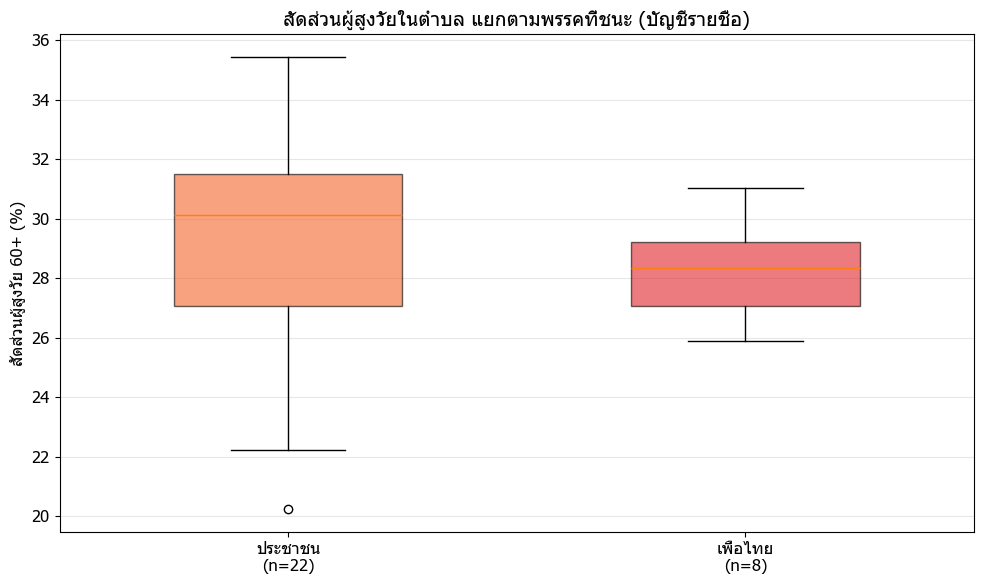

In [6]:
# Box plot: สัดส่วนผู้สูงวัยแยกตามพรรคที่ชนะ
fig, ax = plt.subplots(figsize=(10, 6))

parties_in_data = merged['winner_party'].value_counts()
party_colors = {
    'ประชาชน': '#F4652A',
    'เพื่อไทย': '#E0242B',
    'กล้าธรรม': '#1651B5',
}

data_by_party = []
labels = []
colors = []
for party in parties_in_data.index:
    vals = merged[merged['winner_party'] == party]['pct_elderly']
    data_by_party.append(vals)
    labels.append(f"{party}\n(n={len(vals)})")
    colors.append(party_colors.get(party, '#999999'))

bp = ax.boxplot(data_by_party, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('สัดส่วนผู้สูงวัย 60+ (%)')
ax.set_title('สัดส่วนผู้สูงวัยในตำบล แยกตามพรรคที่ชนะ (บัญชีรายชื่อ)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Scatter: สัดส่วนผู้สูงวัย vs คะแนนพรรค

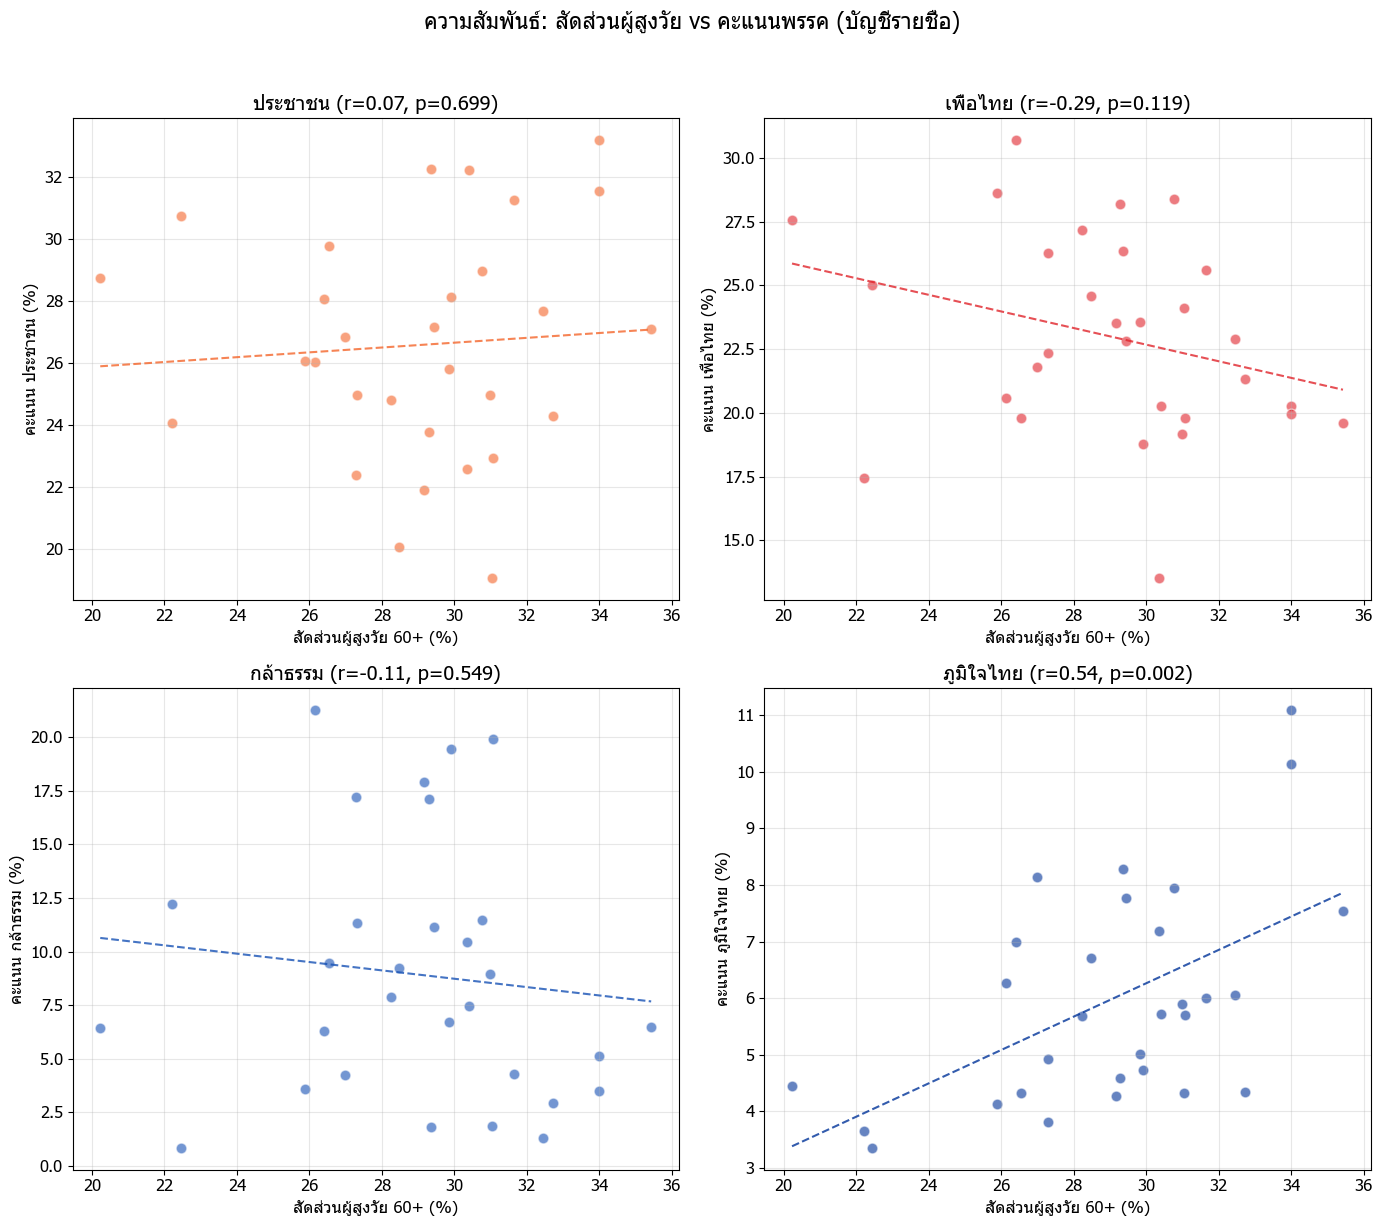

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

party_info = [
    ('ประชาชน', '#F4652A'),
    ('เพื่อไทย', '#E0242B'),
    ('กล้าธรรม', '#1651B5'),
    ('ภูมิใจไทย', '#003399'),
]

for ax, (party, color) in zip(axes.flat, party_info):
    x = merged['pct_elderly']
    y = merged[f'pct_{party}']
    
    ax.scatter(x, y, c=color, alpha=0.6, s=60, edgecolors='white')
    
    # Regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, '--', color=color, alpha=0.8)
    
    ax.set_xlabel('สัดส่วนผู้สูงวัย 60+ (%)')
    ax.set_ylabel(f'คะแนน {party} (%)')
    ax.set_title(f'{party} (r={r_value:.2f}, p={p_value:.3f})')
    ax.grid(alpha=0.3)

plt.suptitle('ความสัมพันธ์: สัดส่วนผู้สูงวัย vs คะแนนพรรค (บัญชีรายชื่อ)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. สัดส่วนผู้สูงวัย vs Turnout & บัตรเสีย

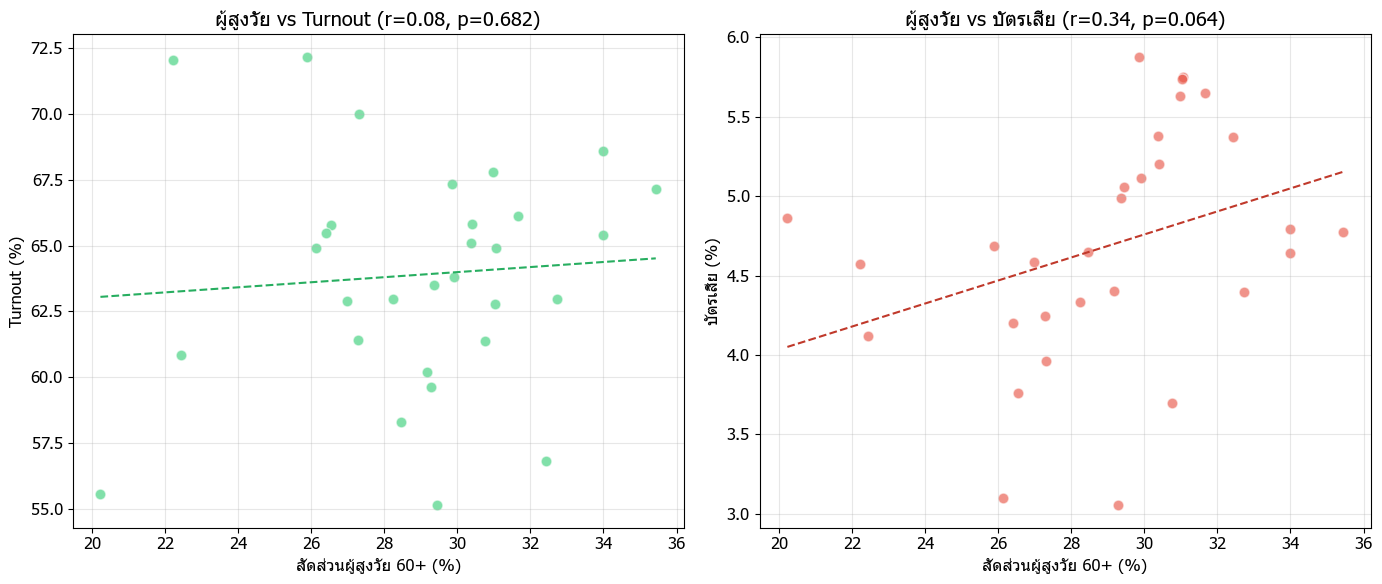

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Turnout
ax = axes[0]
x = merged['pct_elderly']
y = merged['turnout_pct']
ax.scatter(x, y, c='#2ecc71', alpha=0.6, s=60, edgecolors='white')
slope, intercept, r_value, p_value, std_err = stats.linregress(x.dropna(), y.dropna())
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='#27ae60')
ax.set_xlabel('สัดส่วนผู้สูงวัย 60+ (%)')
ax.set_ylabel('Turnout (%)')
ax.set_title(f'ผู้สูงวัย vs Turnout (r={r_value:.2f}, p={p_value:.3f})')
ax.grid(alpha=0.3)

# Invalid ballots
ax = axes[1]
y = merged['invalid_pct']
ax.scatter(x, y, c='#e74c3c', alpha=0.6, s=60, edgecolors='white')
slope, intercept, r_value, p_value, std_err = stats.linregress(x.dropna(), y.dropna())
ax.plot(x_line, slope * x_line + intercept, '--', color='#c0392b')
ax.set_xlabel('สัดส่วนผู้สูงวัย 60+ (%)')
ax.set_ylabel('บัตรเสีย (%)')
ax.set_title(f'ผู้สูงวัย vs บัตรเสีย (r={r_value:.2f}, p={p_value:.3f})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

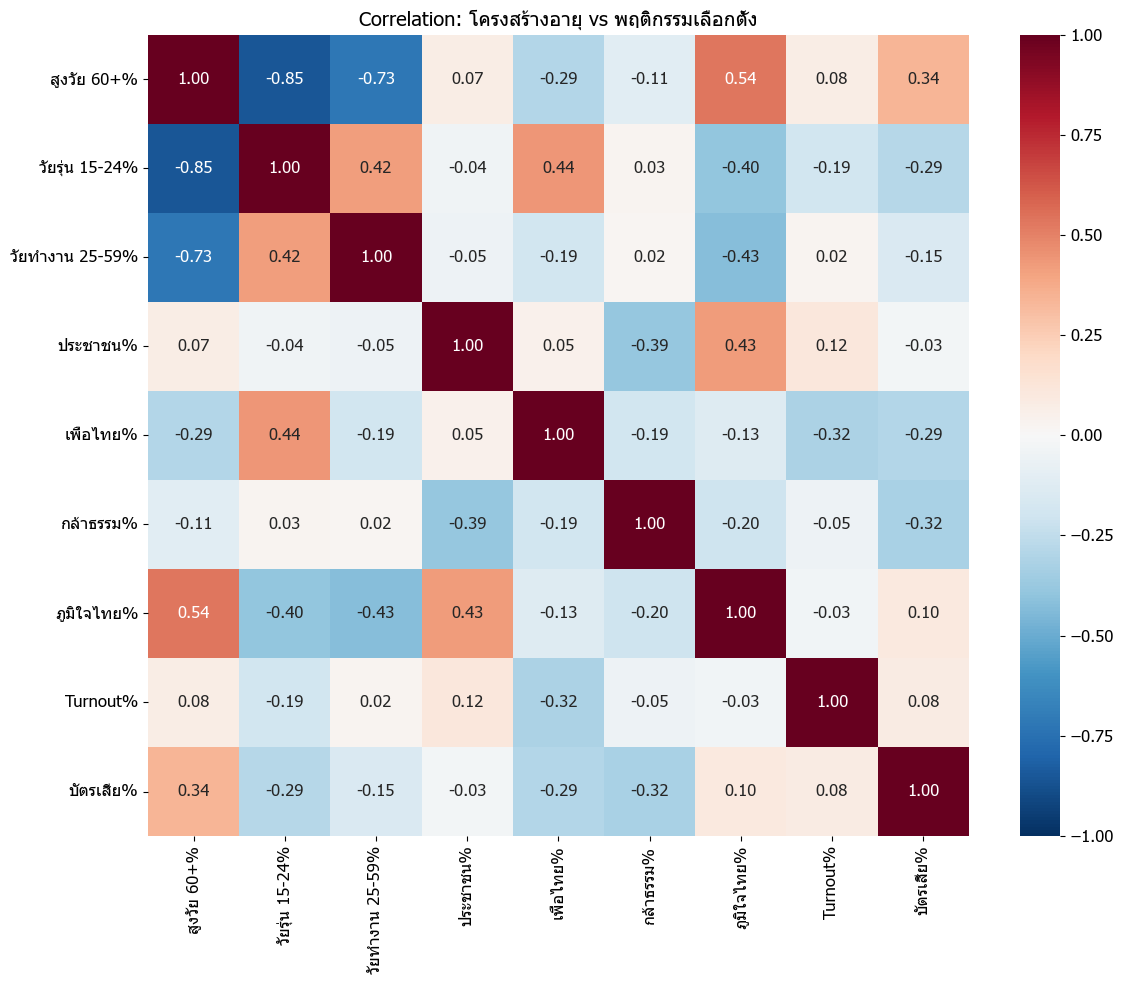

In [9]:
import seaborn as sns

corr_cols = ['pct_elderly', 'pct_youth', 'pct_working',
             'pct_ประชาชน', 'pct_เพื่อไทย', 'pct_กล้าธรรม', 'pct_ภูมิใจไทย',
             'turnout_pct', 'invalid_pct']
corr_labels = ['สูงวัย 60+%', 'วัยรุ่น 15-24%', 'วัยทำงาน 25-59%',
               'ประชาชน%', 'เพื่อไทย%', 'กล้าธรรม%', 'ภูมิใจไทย%',
               'Turnout%', 'บัตรเสีย%']

available_cols = [c for c in corr_cols if c in merged.columns]
available_labels = [corr_labels[i] for i, c in enumerate(corr_cols) if c in merged.columns]

corr = merged[available_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=available_labels, yticklabels=available_labels,
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation: โครงสร้างอายุ vs พฤติกรรมเลือกตั้ง')
plt.tight_layout()
plt.show()

## 6. Age Pyramid เปรียบเทียบตำบล

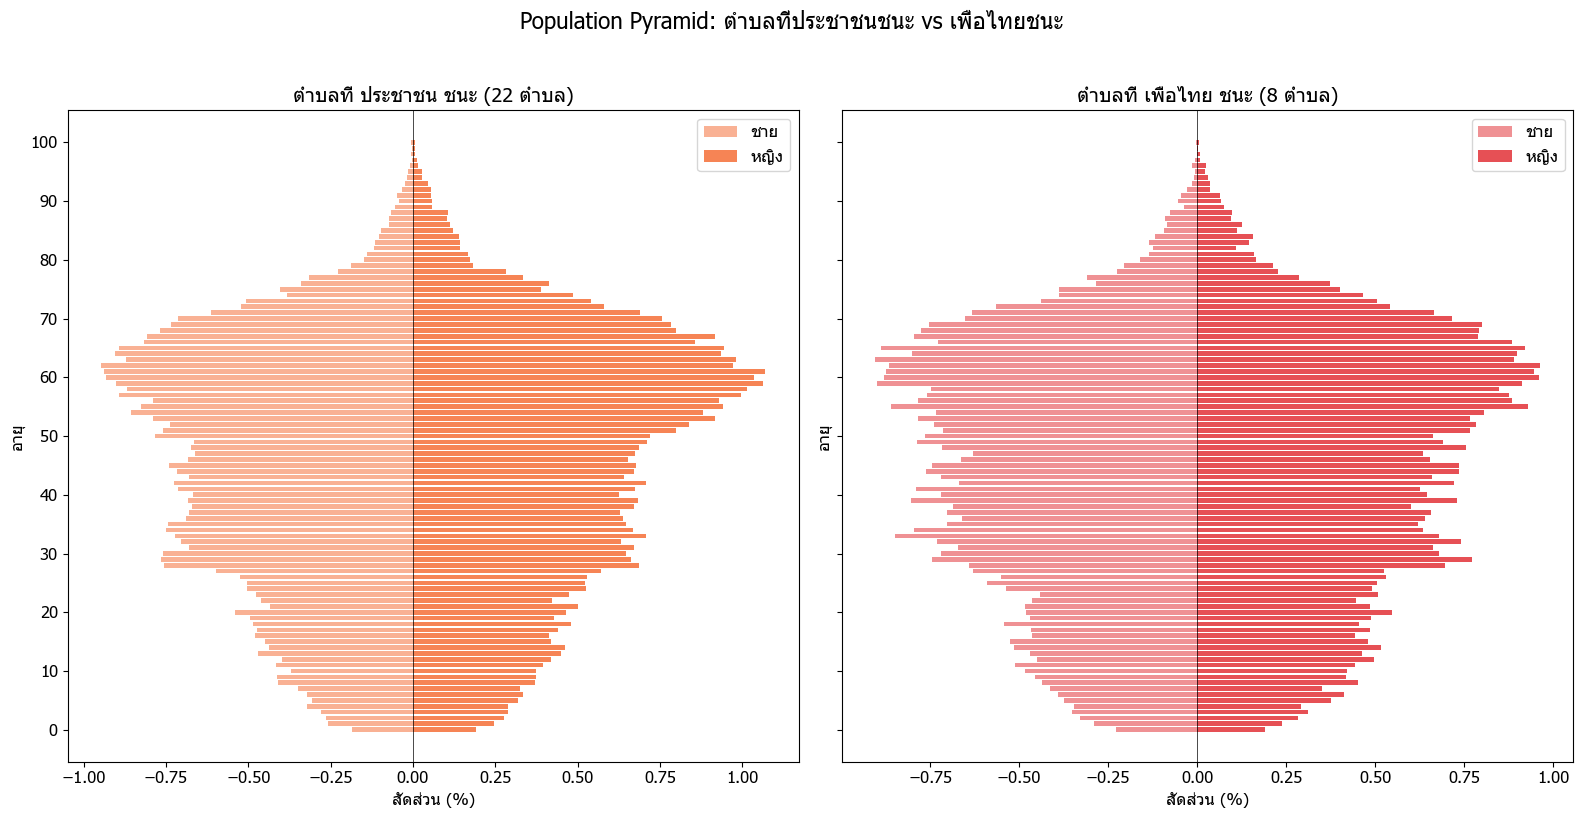

In [10]:
# เปรียบเทียบ age pyramid ระหว่างตำบลที่ประชาชนชนะ vs เพื่อไทยชนะ
pop_merged = pop.merge(winner[['district', 'sub_district', 'winner_party']],
                       left_on=['district', 'sub_district'],
                       right_on=['district', 'sub_district'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for ax, party, color in zip(axes, ['ประชาชน', 'เพื่อไทย'], ['#F4652A', '#E0242B']):
    data = pop_merged[pop_merged['winner_party'] == party]
    n_tambon = data[['district', 'sub_district']].drop_duplicates().shape[0]
    
    age_data = data.groupby('age')[['male', 'female']].sum()
    # Normalize to percentage
    total = age_data['male'].sum() + age_data['female'].sum()
    age_data['male_pct'] = -age_data['male'] / total * 100
    age_data['female_pct'] = age_data['female'] / total * 100
    
    ages = age_data.index
    ax.barh(ages, age_data['male_pct'], color=color, alpha=0.5, label='ชาย')
    ax.barh(ages, age_data['female_pct'], color=color, alpha=0.8, label='หญิง')
    ax.set_title(f'ตำบลที่ {party} ชนะ ({n_tambon} ตำบล)')
    ax.set_xlabel('สัดส่วน (%)')
    ax.set_ylabel('อายุ')
    ax.legend()
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_yticks(range(0, 101, 10))

plt.suptitle('Population Pyramid: ตำบลที่ประชาชนชนะ vs เพื่อไทยชนะ', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. สรุปผล

### คำถาม: ตำบลที่คนแก่เยอะ เลือกพรรคไหน?

ดูจาก:
1. **Box plot** — สัดส่วนผู้สูงวัยแยกตามพรรคที่ชนะ
2. **Scatter + regression** — ความสัมพันธ์ระหว่างสัดส่วนผู้สูงวัยกับคะแนนแต่ละพรรค
3. **Correlation heatmap** — ภาพรวมความสัมพันธ์ทั้งหมด
4. **Age pyramid** — เปรียบเทียบโครงสร้างอายุระหว่างตำบลที่พรรคต่างๆ ชนะ

**หมายเหตุ:** ข้อมูลประชากรเป็นจำนวนผู้มีชื่อในทะเบียนบ้าน ไม่ใช่จำนวนผู้มีสิทธิ์เลือกตั้ง  
ชื่อตำบลบางตำบลอาจ match ไม่ได้ระหว่าง 2 dataset — ตรวจสอบ cell ที่ 4